# VQC Based on IQC:AIL

## Imports

In [1]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter
from qiskit.compiler import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate,Initialize
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report

from imblearn.over_sampling import SMOTE
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd


## Base de Dados

In [2]:
#Gerando o dataset
iris = fetch_ucirepo(id=53)
# data (as pandas dataframes) 
X_iris = iris.data.features 
X_iris = X_iris.values
y_iris = iris.data.targets
y_iris = y_iris.values

#Parâmetros
RANDOM_SEED = 1
LEARNING_RATE = 0.01
N_FEATURES = len(X_iris[0])
N_SAMPLES = len(X_iris)
N_PRINTINGS = N_SAMPLES//2
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,0.1)
QUBITS=[i for i in range(N_QUBITS)]
N_SHOTS=2048
N_ITER=200

## Tratamento do Dataset

In [3]:
def normalize_iqc_ail(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        data = preprocessing.normalize(data,axis=0,norm='l2')
        '''
        Perceba que normalizando apenas a coluna, podemos ter amplitudes dos estados em que a norma do estado não fosse igual a 1. Para resolvermos isso, devemos
        normalizar as linhas entre si

        '''
        data = preprocessing.normalize(data,axis=1,norm='l2')
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normaliza a linha entre [-1,1]
    return data
    
X_iris_iqc_ail_coluna=normalize_iqc_ail(X_iris, normalize_col=True, normalize_lin=False)
X_iris_iqc_ail_linha=normalize_iqc_ail(X_iris,normalize_col=False,normalize_lin=True)

#### Boxplot IQC:AIL Column Normalized

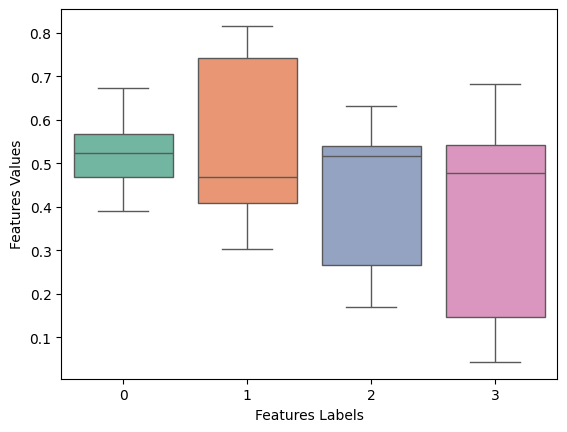

In [4]:
fig, ax = plt.subplots()
sns.boxplot(X_iris_iqc_ail_coluna, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_iris_iqc_ail_coluna.svg')

#### Boxplot IQC:AIL Line Normalized

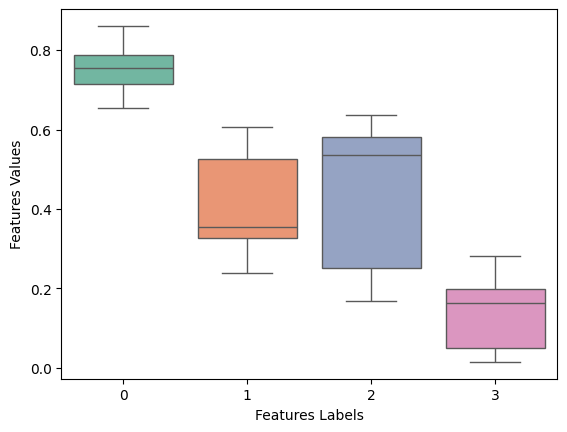

In [5]:
fig, ax = plt.subplots()
sns.boxplot(X_iris_iqc_ail_linha, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_iris_iqc_ail_linha.svg')

## Quantum Circuit

Não geraremos imagens ainda

### Circuito IQC em Pennylane

Ainda em construção

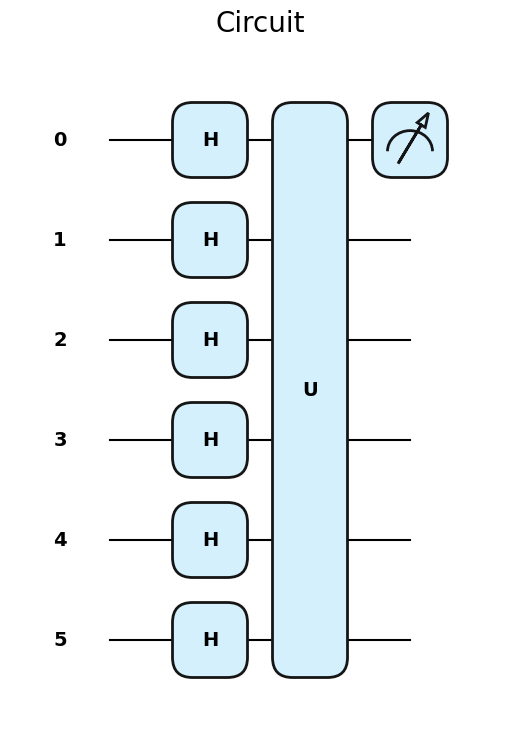

In [ ]:
N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X_iris))]
j=int(np.random.choice(lista))

w=weights

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_iris_new=list(X_iris[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_iris_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_iris_new)*w.T
else:
    sigmaE=np.diag(X_iris_new)*w.T

#Operador Unitário
U=pnp.matrix(expMatrix(1j*pnp.kron(sigmaQ,sigmaE)))
#U=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])

#tem que inicializar o device
qubits=[i for i in range(N_qubits)]
dev = qml.device("default.qubit", wires = qubits)

@qml.qnode(dev)
def circuit():

    #https://docs.pennylane.ai/en/stable/introduction/operations.html lista dos operadores do pennylane
    #colocar as portas aq
    for i in range(N_qubits):
        qml.Hadamard(wires=[i])
    qml.QubitUnitary(U, wires=qubits)

    return qml.density_matrix([0]) #Retorna a matriz reduzida do qubit alvo

state=circuit
#print(state())
qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl(circuit)()
ax.set_aspect('equal')
fig.set_figwidth(20)
plt.title("Circuit",size = 20)
plt.show()

In [11]:
print(U.shape)

(64, 64)


### Circuito IQC em Qiskit

X[96]: [np.float64(0.21702133095999984), np.float64(0.24249387268728081), np.float64(0.20722489192860727), np.float64(0.1150790261435985), np.float64(0.41300531491776443), np.float64(0.13848490415072998), np.float64(0.05145605472763242), np.float64(0.12892246374754104), np.float64(0.3741757553955815), np.float64(0.30445968350705316), np.float64(0.08131579270279082), np.float64(0.22431690993768877), np.float64(0.06869539543040762), np.float64(0.029055887279986075), np.float64(0.11153369949436813), np.float64(0.06318066883348972), np.float64(0.02519004639002397), np.float64(0.2537859996578669), np.float64(0.17769279258685833), np.float64(0.07657941504040587), np.float64(0.15374350675272025), np.float64(0.2092130280225448), np.float64(0.13937649559851423), np.float64(0.06719808539016063), np.float64(0.2494581517714743), np.float64(0.056724813632677076), np.float64(0.03508217916574045), np.float64(0.17827628663921144), np.float64(0.11509452778536053), np.float64(0.10829576594009413), 0, 0]

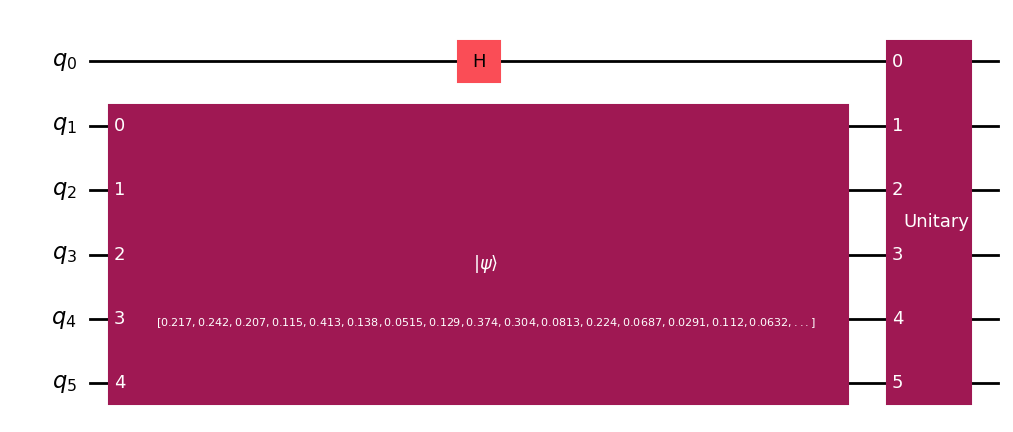

In [ ]:
# Criando o circuito com um vetor qualquer do dataset para exemplificar

N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X_iris))]
j=int(np.random.choice(lista))

w=weights

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=N_QUBITS

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

X_iris_new=list(X_iris_iqc_ail_coluna[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_iris_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(w)
else:
    sigmaE=np.diag(w)

# IQC

qc = QuantumCircuit(N_qubits)
qc.initialize(X_iris_new, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
qc.h(0)



#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z





#Debugando
print(f'X[{j}]:', X_iris_new, '; w:', w,'\n')
print('sigmaE')
print(sigmaE)
#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

qubits=[i for i in range(N_qubits)]
# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)
qc.draw("mpl")

In [31]:
#Decompondo em portas U3 e CX
qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
print(dict(qc.count_ops()))
if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
    display(qc.draw('mpl'))

{'u3': 1445, 'cx': 940, 'reset': 5}


#### Statevector e Matriz Densidade

Aqui vamos avaliar o estado depois da evolução 

##### Statevector

<IPython.core.display.Latex object>

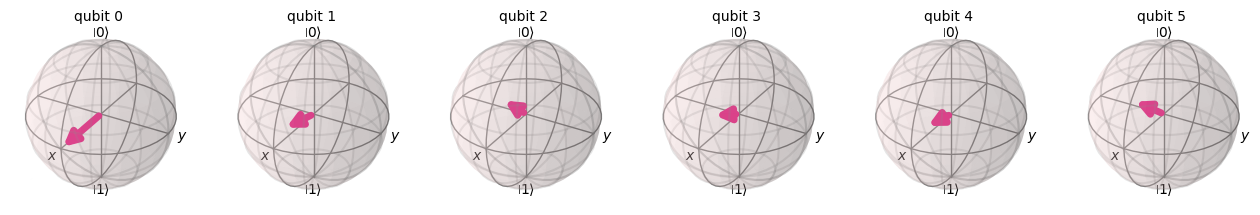

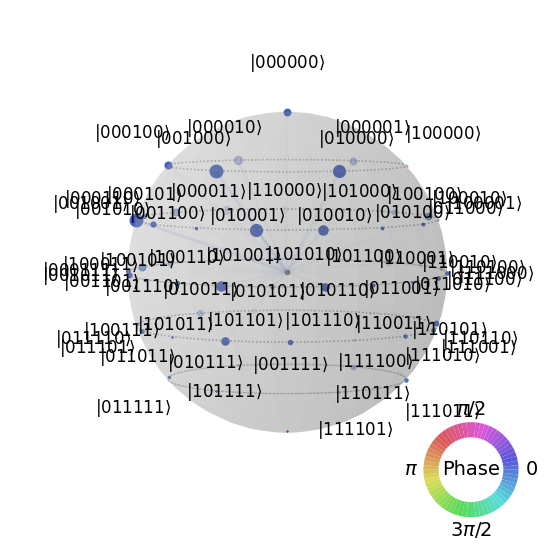

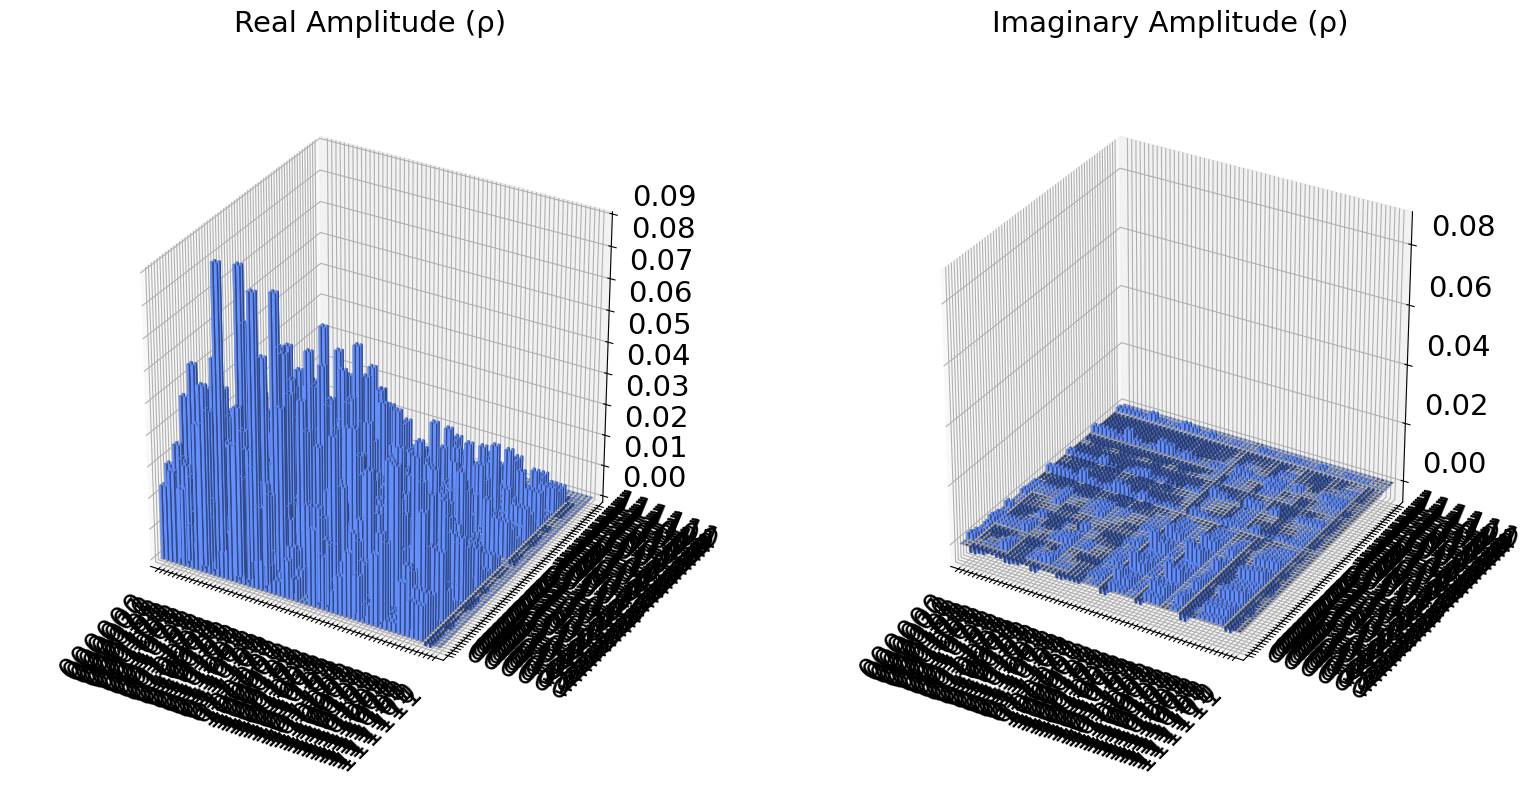

In [32]:
#Estado completo
sv = Statevector(qc)
'''
'mpl' is not a valid option for drawing Statevector objects. Please choose from:
            'text', 'latex', 'latex_source', 'qsphere', 'hinton',
            'bloch', 'city' or 'paulivec'
'''

display(sv.draw("latex")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("bloch")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("qsphere")) #Plota o vetor de estado em uma esfera que mapeia o espaço tensorial originado pelos espaços de Hilbert
display(sv.draw("city")) #Plota o histograma da matriz densidade SEM MEDÍ-LA


##### Partial Trace

Vamos traçar o sis. auxiliar

In [33]:
rho = partial_trace(sv,qubits[1:])
print(rho)

def blochvector(rho):
    x = np.trace(matriz_pauli_x@rho.data)
    y= np.trace(matriz_pauli_y@rho.data)
    z = np.trace(matriz_pauli_z@rho.data)
    return [x,y,z]
blochvector(rho)


DensityMatrix([[0.5+0.00000000e+00j, 0.5-4.63518113e-15j],
               [0.5+4.63518113e-15j, 0.5+0.00000000e+00j]],
              dims=(2,))


[np.complex128(1.0000000000000007+0j),
 np.complex128(9.270362255620057e-15+0j),
 np.complex128(1.1102230246251565e-15+0j)]

##### Ponto na Casca da superfície da Esfera de Bloch

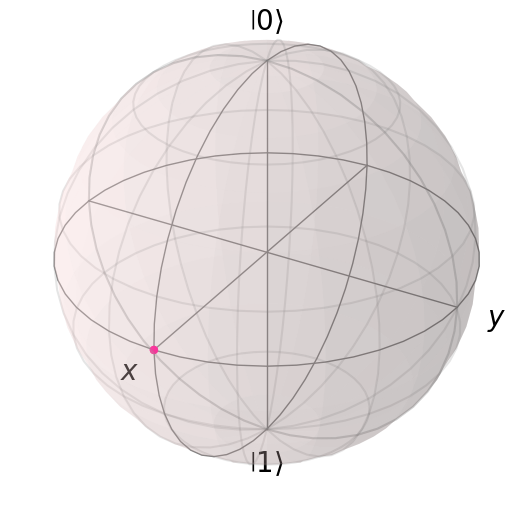

In [34]:
b = qutip.Bloch()
b.point_default_color=['deeppink']
b.add_points(blochvector(rho))

b.render()
b.show()

##### Matriz Densidade

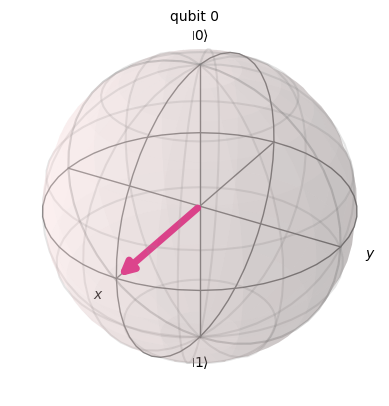

In [35]:
#Ao traçar fora o ambiente
rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
#rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:]).data

display(rho_res.draw('bloch'))

Como podemos observar, conseguimos marcar o ponto, na superfície da esfera, ao qual o autovetor do SISTEMA pertence. E se fizermos isso durante todo o código?

##### Negatividade

In [18]:
Negativity = (np.linalg.norm(rho_res)-1)/2

#### Executando o Circuito

{'000011': 10, '110100': 6, '101100': 24, '111010': 11, '100110': 16, '001111': 28, '000000': 28, '110111': 2, '101000': 15, '110010': 19, '000101': 20, '101110': 14, '110000': 14, '000111': 13, '100111': 15, '100001': 1, '111111': 8, '001010': 25, '100010': 2, '001011': 32, '111110': 12, '010100': 24, '011100': 19, '011010': 17, '001001': 15, '001100': 13, '100011': 18, '111101': 20, '011101': 20, '011110': 14, '010001': 22, '110110': 14, '101010': 15, '000001': 26, '001110': 19, '111011': 11, '100101': 12, '101011': 3, '110101': 25, '000010': 27, '110001': 13, '101111': 13, '000110': 14, '000100': 21, '110011': 12, '101101': 30, '010110': 22, '011000': 26, '011011': 31, '010111': 27, '010000': 18, '011111': 20, '001000': 20, '111100': 8, '100100': 7, '001101': 6, '111001': 10, '010011': 13, '010101': 12, '101001': 16, '100000': 2, '011001': 16, '010010': 12, '111000': 6}


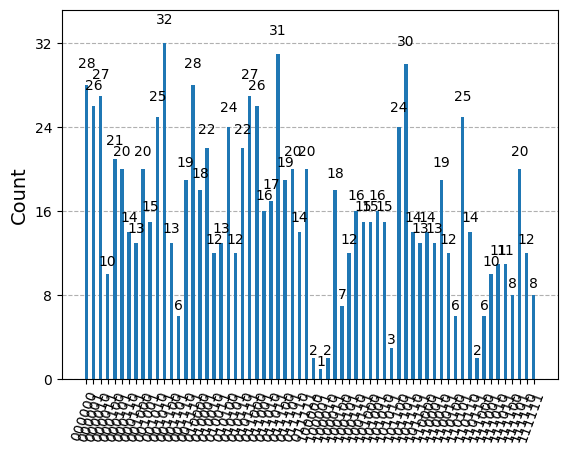

In [19]:
#Executar o circuito
def run_qasm_counts(circ, shots=1024):
  qc.measure_all()
  qasm_simulator = Aer.get_backend("qasm_simulator")
  job = qasm_simulator.run(qc, shots=shots)
  result = job.result()
  return result.get_counts()

counts = run_qasm_counts(qc)
print(counts)
plot_histogram(counts)

## Função que junta tudo até agora

In [ ]:
def blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z):
    x_bloch = np.trace(matriz_pauli_x@rho_cog.data)
    y_bloch = np.trace(matriz_pauli_y@rho_cog.data)
    z_bloch = np.trace(matriz_pauli_z@rho_cog.data)
    return [x_bloch,y_bloch,z_bloch]
    
#Executar o circuito
def run_qasm_counts(qc, shots=N_SHOTS):
    qc.measure_all()
    qasm_simulator = Aer.get_backend("qasm_simulator")
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    return result.get_counts()

def cirq_iqc_ail(data,contador,w=weights,qubits=QUBITS, N_qubits=N_QUBITS, N_atributos=N_FEATURES, printar_cirq=False):

    X_blobs_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            w=np.append(w,0)
            X_blobs_new=np.append(X_blobs_new,0)
        sigmaE=np.diag(w)
    else:
        sigmaE=np.diag(w)
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC:AIL

    qc = QuantumCircuit(N_qubits)

    qc.initialize(X_blobs_new, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(0)

    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_complete_U_iris_iqc_ail.svg')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['cx']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_iris_iqc_ail.svg')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_iris_iqc_ail.svg')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_iris_iqc_ail.svg')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_iris_iqc_ail.svg')
    if printar_cirq==True:
        display(sv.draw("latex"))

    
    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_iris_iqc_ail.svg')
    
    rho_cog=partial_trace(sv,qubits[1:])
    #rho_cog = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
    if printar_cirq==True:
        print(rho_cog)

    return blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z)

## Esfera de Bloch do Circuito

In [ ]:
def esfera_bloch_IQC_AIL(X,counter,norma,weights=weights,printar_esf=False):
    point_states=[]
    for k in range(0,N_SAMPLES):
        point_states.append(cirq_iqc_ail(X[k],k,w=weights))

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    if printar_esf==True:
        b.show()

    bb = b.fig
    bb.savefig(f'Bloch_geral_iris{counter}_IQC_AIL_{norma}.svg')

z1=esfera_bloch_IQC_AIL(X_iris_iqc_ail_coluna,1,'coluna')
z2=esfera_bloch_IQC_AIL(X_iris_iqc_ail_linha,1,'linha')

## Treinamento

### Class IQC

In [6]:
def update_weights(weights_list, y, z, x, p, n, coupling_constants):
  """
    Updates the weights. Equation #34 in the Article.
    
    y is the expected classification [0, 1];
    z is the actual classification [0, 1];
    x is the attribute vector;
    p is the probability of the class 1 (0, 1), powered to 2 (p²);
    n is the learning rate.
  """

  # We want to have multiple environments, thus we need to have a list of weights for each of them
  if not(isinstance(weights_list, (list, np.ndarray)) and all(isinstance(item, (list, np.ndarray)) for item in weights_list)):
    weights_list = np.array([weights_list], dtype=complex)

  losses = []
  new_weights = []
  for index, weights in enumerate(weights_list):
    # We need a new instance of the weights, otherwise we'll have problem
    weights = weights.copy()

    # Current loss for this environment
    loss_derivative_on_weight = coupling_constants[index]*(1-p)*x

    # Accumulating losses throughout the environment
    losses.append(loss_derivative_on_weight)
    for loss_index in range(index):
      loss_derivative_on_weight = loss_derivative_on_weight + (coupling_constants[loss_index]*losses[loss_index])

    # Applying losses
    weights = weights-n*(z-y)*loss_derivative_on_weight
    weights[np.isnan(weights)] = 0
    
    # Saving new weights list
    new_weights.append(weights)
  return new_weights

def update_batched_weights(weights_list, accumulated_loss, n, coupling_constants):
  """
    Updates the weights. Equation #34 in the Article.
    
    y is the expected classification [0, 1];
    z is the actual classification [0, 1];
    x is the attribute vector;
    p is the probability of the class 1 (0, 1), powered to 2 (p²);
    n is the learning rate.
  """
  if not(isinstance(weights_list, list) and all(isinstance(item, list) for item in weights_list)):
    weights_list = np.array([weights_list], dtype=complex)

  losses = []
  new_weights = []
  for index, weights in enumerate(weights_list):
    # We need a new instance of the weights, otherwise we'll have problem
    weights = weights.copy()

    # Current loss for this environment
    current_loss = coupling_constants[index]*accumulated_loss

    # Accumulating losses throughout the environment
    losses.append(current_loss)
    for loss_index in range(index):
      current_loss = current_loss + (coupling_constants[loss_index]*losses[loss_index])

    # Eq 34
    weights = weights-(n*current_loss)
    weights[np.isnan(weights)] = 0
    new_weights.append(weights)
  return new_weights
    
class IQCClassifier(ClassifierMixin, BaseEstimator):
    """
        Returns an Scikit-Learn based estimator that uses ICQ classificator (https://ieeexplore.ieee.org/document/9533917) to classify instances.

        It estimates only binary classifications. For multi-class problems, you can use e.g. sklearn.multiclass.OneVsOneClassifier or sklearn.multiclass.OneVsRestClassifier.

        Attributes:
            classifier_function (fun): check /helpers/icq_executions.py file to see available functions

            dic_training_params["accuracy_succ"] (float): accuracy considered as successful training.

            dic_training_params["sigma_q_params"] (4 sized array): weights for sigma Q sum. See ../helpers/icq_methods.get_weighted_sigmaQ for more info.

            dic_training_params["max_iter"] (int): max number of training epochs.

            dic_training_params["reset_weights_epoch"] (int): max amount of epochs that a random weight should be trained. If reached, it will reset the weights to random numbers again and will keep training. If set to 0, it will never be reset.

            dic_training_params["learning_rate"] (float): weights' learning accuracy.

            dic_training_params["plot_graphs_and_metrics"] (boolean): prints training best weights, accuracy and epoch x accuracy graph.

            dic_training_params["do_classes_refit"] (boolean): resamples classes in order to have same amount of 0s and 1s instances. See ../helpers/database_helpers.replicate_classes

            dic_training_params["batch"] (integer): batch size used during training.

            dic_training_params["coupling_constants"] (array): coupling constants of each environment that will colide in the classifier

            accuracys_during_training_ (array): accuracy throughout the training.

            X_ (array of arrays): instances attributes used for training.

            Y_ (array): instances classes used for training.

            weight_ (array): best weights from training.

            accuracy_ (float): best accuracy from training.

            negativity_ (array of floats): array of floats for each X passed in predict or predict_proba methods
    """
    def __init__(self, 
                 classifier_function, 
                 dic_classifier_params,
                 dic_training_params):
        
        self.classifier_function = classifier_function
        self.dic_classifier_params = dic_classifier_params
        self.dic_training_params = dic_training_params
        self.accuracy_succ = dic_training_params["accuracy_succ"]
        self.max_iter = dic_training_params["max_iter"]
        self.reset_weights_epoch = dic_training_params["reset_weights_epoch"]
        self.random_seed = dic_training_params["random_seed"]
        self.learning_rate = dic_training_params["learning_rate"]
        self.plot_graphs_and_metrics = dic_training_params["plot_graphs_and_metrics"]
        self.do_classes_refit = dic_training_params["do_classes_refit"]
        self.batch = dic_training_params["batch"]
        if "coupling_constants" not in self.dic_training_params:
            dic_training_params["coupling_constants"] = [1]
        self.coupling_constants = dic_training_params["coupling_constants"]
        self.negativity_ = []
        self.entropy_ = []

    def fit(self, X, y):
        """
            Trains the ICQ classifier using X as instances attributes and y as instances classes.

            To have a fair training, it replicates the minority class to have the same number of instances as the majority class. See ../helpers/database_helpers.replicate_classes for more info or to change the replication approach.

            X: N x M matrix, where M is the number of attributes and N is the number of instances.
            y: N sized array of 0s or 1s values, where N is the number of instances.

            Returns the trained classifier.
        """
        # Replicates classes to have same number of 0s and 1s examples
        if (self.do_classes_refit):
            smote=SMOTE()
            X,y = smote.fit_resample(X, y)
            
        # Check that X and y have correct shape (i.e. same amount of examples)
        X, y = check_X_y(X, y)

        # Store the classes seen during fit
        self.classes_ = unique_labels(y)
        
        # Creates weights based on a [-1, 1] uniform distribution
        low = -1
        high = 1
        dimensions = len(X[0])
        num_of_instances = len(X)
        
        # Setting random seed to have always same result
        np.random.seed(self.random_seed)
        weights = []
        for _ in self.dic_training_params["coupling_constants"]:
            weights.append(np.random.uniform(low=low, high=high, size=(dimensions,)))
        
        ITERATION = 0
        best_weight = None
        best_accuracy = 0.0
        accuracy = 0
        self.accuracy_during_training_ = []
        # There is no need to calculate negativity nor entropy now, only on the Predict level
        self.dic_classifier_params["calculate_negativity"] = False
        self.dic_classifier_params["calculate_entropy"] = False
        
        # Executing the training itself
        while ITERATION < self.max_iter:
            accuracy = 0
            accumulated_loss = np.zeros((dimensions))
            
            # Training step
            for i, (x_train, y_train) in enumerate(zip(X, y)):
                # Execute the classifier with the weights we have now...
                z, p_cog, _ = self.classifier_function(vector_x=x_train, vector_ws=weights, dic_classifier_params=self.dic_classifier_params)

                accumulated_loss += (z - y_train) * x_train
                if self.batch <= 1:
                    weights = update_weights(weights, y_train, z, x_train, p_cog, n=self.learning_rate, coupling_constants=self.coupling_constants)
                elif i % self.batch == 0 or i == num_of_instances - 1:
                    weights = update_batched_weights(weights, accumulated_loss/self.batch, self.learning_rate, coupling_constants=self.coupling_constants)
                    accumulated_loss = np.zeros((dimensions))
                    
            # After executing everything and updating the weights for the whole set example, we compute current accuracy
            for x_train, y_train in zip(X, y):
                # Classify using current weight...
                z, p_cog, _ = self.classifier_function(vector_x=x_train, vector_ws=weights, dic_classifier_params=self.dic_classifier_params)            
                
                # ... and checks if we got it right
                if z == y_train:
                    accuracy +=1
            
            # Computing actual accuracy...
            accuracy = accuracy/len(y)
            self.accuracy_during_training_.append(accuracy)
            ITERATION += 1

            # ... and checking if this is the best one so far, or if it's the first iteration, take the weights even if accuracy is zero
            if (accuracy > best_accuracy) or ITERATION == 1:
                best_weight = weights.copy()
                best_accuracy = accuracy

        self.accuracy_ = best_accuracy
        self.weight_ = best_weight
        self.X_ = X
        self.y_ = y
        
        if self.plot_graphs_and_metrics:
            print("best weight", best_weight)
            print("best accuracy", best_accuracy)
        
        # Return the classifier
        return self

    def predict(self, X):
        """
            Returns the predicted class for each X instance - either 0 or 1.
        """
        # Check is fit had been called
        check_is_fitted(self, ['X_', 'y_', 'weight_'])

        # Input validation
        X = check_array(X)
        
        # Classifies each instance
        outputs = []
        self.negativity_ = []
        self.entropy_ = []
        self.dic_classifier_params["calculate_negativity"] = True
        self.dic_classifier_params["calculate_entropy"] = True
        for x in X:                   
            z, _, output_dict = self.classifier_function(vector_x=x, vector_ws=self.weight_, dic_classifier_params=self.dic_classifier_params)

            outputs.append(z)
            self.negativity_.append(output_dict["negativity"])
            self.entropy_.append(output_dict["entropy"])

        # Returns either 0 or 1
        self.negativity_ = np.mean(self.negativity_)
        self.entropy_ = np.mean(self.entropy_)
        return outputs

    def predict_proba(self, X):
        """
            Returns the probability of each instance being of each class - either 0 or 1.
        """
        outputs = []
        self.negativity_ = []
        self.entropy_ = []
        self.dic_classifier_params["calculate_negativity"] = True
        self.dic_classifier_params["calculate_entropy"] = True
        for x in X:                   
            _, p_cog, output_dict = self.classifier_function(vector_x=x, vector_ws=self.weight_, dic_classifier_params=self.dic_classifier_params)

            outputs.append([1-p_cog.real, p_cog.real])
            self.negativity_.append(output_dict["negativity"])
            self.entropy_.append(output_dict["entropy"])

        # Returns the probability of being either 0 or 1
        self.negativity_ = np.mean(self.negativity_)
        self.entropy_ = np.mean(self.entropy_)           
        return np.array(outputs)

def get_stratified_kfold(k_folds=10, random_seed=1):
    return StratifiedKFold(n_splits=k_folds, random_state=random_seed, shuffle=True)

def print_metrics(scores, f1scores):
    print("Scores:", scores)
    print("Best score:", np.max(scores))
    print("F1-Scores:", f1scores)
    print("Max F1-Score:", np.max(f1scores))
    print("Avg score:", np.mean(scores))
    print("Avg F1-Score:", np.mean(f1scores))


In [7]:
def execute_training_test_k_fold(
                X, 
                y, 
                k_folds=10,
                random_seed = 1, 
                classifier_function=None, 
                dic_classifier_params={},
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params={},
                print_each_fold_metric=False,
                print_avg_metric=True):
    """
        Executes ICQ classifier against an dataset using classifier_function as classifier (see /helpers/icq_executions.py for more info).
        As for datasets, we need it to return a pair X, y. See database_helpers for examples
    """

    if "classical_classifier" in dic_training_params:
        classifier = dic_training_params["classifier"] 
        classical_classifier = True
    else:
        classical_classifier = False
        
    # Creating K-Fold to use
    skf = get_stratified_kfold(k_folds=k_folds, random_seed=random_seed)

    scores = []
    f1scores = []

    negativities = [[]]
    entropies = [[]]

    normalize_axis = 0
    if "normalize_axis" in dic_classifier_params:
        normalize_axis = dic_classifier_params["normalize_axis"]

    # Training the classifier itself
    for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train = X[train_index]
        X_test = X[test_index]

        y_train = y[train_index]
        y_test = y[test_index]

        normalized_X_train = preprocessing.normalize(X_train, axis=normalize_axis) # Default is 1 (by line)
        normalized_X_train = preprocessing.normalize(normalized_X_train, axis=1) # This prevents states with norms not equal to 1
        normalized_X_test  = preprocessing.normalize(X_test, axis=normalize_axis)
        normalized_X_test  = preprocessing.normalize(normalized_X_test, axis=1) # This prevents states with norms not equal to 1
        
        if classical_classifier: 
            clf = one_vs_classifier(classifier).fit(normalized_X_train, y_train)  
        else:
            clf = one_vs_classifier(
                    IQCClassifier(
                        classifier_function=classifier_function, 
                        dic_classifier_params=dic_classifier_params,
                        dic_training_params=dic_training_params), n_jobs=-1, verbose=1).fit(normalized_X_train, y_train)

        score = clf.score(normalized_X_test, y_test)
        f1score = f1_score(clf.predict(normalized_X_test), y_test, average='macro')

        if not(classical_classifier):
            while len(negativities) < len(clf.estimators_):
                negativities.append([])
                entropies.append([])
            
            index = 0
            for estimator in clf.estimators_:
                # negativities variable will look like this:
                # negativities[0] = all folds mean(negativity) for class 0 - which means that len(negativities[0]) = k_folds;
                # so if we want to take average negativity of class 0 for all folds, we need to take mean(negativities[0]).
                # Same goes for entropies
                negativities[index].append(estimator.negativity_)
                entropies[index].append(estimator.entropy_)
                index = index + 1

        scores.append(score)
        f1scores.append(f1score)

        if print_each_fold_metric:
            y_pred = clf.predict(normalized_X_test)
            print("K-Fold #" + str(i))

            # Since negativities and Entropies gets the mean per fold, the info we want is in the last one.
            print("Mean negativities for all classes:", [neg[-1] for neg in negativities])

            # Actual report
            print(classification_report(y_test, y_pred,zero_division=0))
            print("-------------------------------------------------------------------------------------------------------------------")
    
    if print_avg_metric:
        print("AVG: Scores =", np.mean(scores), 
              "F1-Scores =", np.mean(f1scores), 
              "Negativity =", [np.mean([neg[i] for neg in negativities]) for i in range(len(unique_labels(y)))])

    output_dict = {}
    output_dict["negativities"] = negativities
    return scores, f1scores, output_dict

### iqc_clf

In [8]:
from sympy import Matrix

def generate_output_matrix_string(matrix):
    return str(Matrix(matrix)).replace("[", "{").replace("]", "}").replace("Matrix", "").replace("(", "").replace(")", "")

def get_sigmaE(vector_x, vector_w, dic_classifier_params):
    """
        Multiplies the input (vector_x) by the weights (vector_w), resulting in a diagonal matrix. 
        It discards any imaginary part vector_x and vector_w might have.
        Equivalent of Equation #17 in the Article.
    """
    if ("operation_for_sigma_e" in dic_classifier_params and dic_classifier_params["operation_for_sigma_e"] == "sum"):
        return np.diag(vector_x) + np.diag(vector_w)
    else:
        return np.multiply(np.diag(vector_x), vector_w.T)

def get_weighted_sigmaQ(param):
    """
        returns param[0]*sigmaX + param[1]*sigmaY + param[2]*sigmaZ + param[3] * identity to get sigmaQ.
        - sigmaX comes from Equation #7 = [0, 1   1, 0]
        - sigmaY comes from Equation #8 = [0, -i  i, 0]
        - sigmaZ comes from Equation #9 = [1, 0   0, -1]
        - identity is the matrix [1, 0  0, 1]
        Equivalent of Equation #16 in the Article.
    """
    sigmaX = np.array([[0,1], [1,0]])
    sigmaY = np.array([[0,-1j], [1j,0]])
    sigmaZ = np.array([[1,0], [0,-1]])
    identity = np.array([[1, 0], [0, 1]])
    sigmaQ = (param[0]*sigmaX) + (param[1]*sigmaY) + (param[2]*sigmaZ) + (param[3]*identity)
    sigmaq_trace = np.trace(sigmaQ)
    if (sigmaq_trace > 0):
        return np.array(sigmaQ) / sigmaq_trace
    else:
        return np.array(sigmaQ)

def get_sigmaQ_from_polar_coord(param):
    """
        param should be an array that pulls:
        - r = param[0]
        - theta = param[1]
        - phi = param[2]

        returns (identity + (rx * sigmaX) + (ry * sigmaY) + (rz * sigmaZ))/2 to get sigmaQ.
        - identity is the matrix [1, 0    0, 1]
        - sigmaX comes from Equation #7 = [0, 1   1, 0]
        - sigmaY comes from Equation #8 = [0, -i  i, 0]
        - sigmaZ comes from Equation #9 = [1, 0   0, -1]

        where:
        - rx = r * sin(theta) * cos(phi)
        - ry = r * sin(theta) * sin(phi)
        - rz = r * cos(theta)
        
        It's an improved version of Equation #16 from the article, since we need it to sum up to 1.
    """
    # First we retrieve the params
    r = param[0]
    theta = param[1]
    phi = param[2]

    # Then we find out what are our rx, ry and rz
    rx = r * np.sin(theta) * np.cos(phi)
    ry = r * np.sin(theta) * np.sin(phi)
    rz = r * np.cos(theta)

    # Latest part is define sigmaX, sigmaY and sigmaZ from Equations #7, #8 and #9 respectively
    sigmaX = np.array([[0,1], [1,0]])
    sigmaY = np.array([[0,-1j], [1j,0]])
    sigmaZ = np.array([[1,0], [0,-1]])

    # Plus the identity which is needed
    identity = np.array([[1, 0], [0, 1]])

    # Now we return the calculation
    return (identity + (rx * sigmaX) + (ry * sigmaY) + (rz * sigmaZ))/2

def get_U_operator(sigmaQ, sigmaE):
    """
        Makes the exponential matrix of tensor product between sigmaQ and sigmaE and multiplies it by j. 
        
        Equivalent of Equation #15 in the Article.
    """
    return np.matrix(expMatrix(1j*np.kron(sigmaQ, sigmaE)))

def get_p(psi):
    """
        Creates a matrix out of psi and multiply it against its inverse, resulting in a column vector in the form [[alfa]. [beta]].
        
        Does the operation |psi><psi| from Equation #18 or #19 in the Article.
    """
    psi = np.matrix(psi)
    return psi * psi.getH()

def normalize(x):
    return x / (np.linalg.norm(x) + 1e-16)

def get_negativity(rho, dim):
    """
        Returns the Negativity associated with densitiy matrix rho.
        See definition at: https://en.wikipedia.org/wiki/Negativity_(quantum_mechanics)
        See implementation at: https://toqito.readthedocs.io/en/latest/_autosummary/toqito.state_props.negativity.html
    """
    return state_props.negativity(rho, dim)

def get_entropy(rho):
    """
        Returns the Negativity associated with densitiy matrix rho.
        See definition at: https://en.wikipedia.org/wiki/Negativity_(quantum_mechanics)
        See implementation at: https://toqito.readthedocs.io/en/latest/_autosummary/toqito.state_props.von_neumann_entropy.html
    """
    return state_props.von_neumann_entropy(rho)

def iqc_classifier(vector_x, 
                        vector_ws, 
                        normalize_x=False, 
                        normalize_w=False,  
                        dic_classifier_params={}):
    """
        Applies the a modified version of ICQ classifier using only the math behind the Quantum Classifier described in Interactive Quantum Classifier Inspired by Quantum Open System Theory article. 
        
        It differs from the original ICQ by adding a new component to Sigma Q: sigmaH, which corresponds to a Haddamard's gate. Another difference is that we load the input in the environment instead of having a combination of weights and inputs in sigmaE.

        After doing so, it gets the result of Equation #20 and returns Z as the predicted class and the probability of being the class 1.
        
        Works only for binary classifications, therefore, if the probability of class 0 is needed, it can be 1 - probability of being class 1.

        There are a few possible keys for the dic_classifier_params:
        - sigma_q_params (array) = weights used for calculating sigma_q
        - use_polar_coordinates_on_sigma_q (boolean) = whether to calculate sigma_q using polar coordinates or weighted sum
        - load_inputvector_env_state (boolean) = whether to load input vector on the environment state (True) or on sigma_e (False)
        - operation_for_sigma_e (string) = which operation will be used to combine weights and X for load_inputvector_env_state = False. For now, only "sum" and "mul" are available.
        - calculate_negativity (boolean) = enables the negativity calculation. Check https://en.wikipedia.org/wiki/Negativity_(quantum_mechanics). Uses Toqito implementation: https://toqito.readthedocs.io/en/latest/_autosummary/toqito.state_props.negativity.html
        - ending_hadamard_gate (int) =  adds a Hadamard gate after the U operator
        - use_exponential_on_input (boolean) = does the Euler exponential on the input data after normalizing (if applied)

        To have the original ICQ Classifier, you can have:
        normalize_x = False
        normalize_w = False
        dic_classifier_params["load_inputvector_env_state"] = False
        dic_classifier_params["sigma_q_params"] = [1, 1, 1, 0]

        returns (z, p_cog_new_11_2, output_dict)

        output_dict contains:
        - U_operators = list of used U_operators
        - negativity = negativity associated with that entry
        - entropy = entropy associated with that entry
    """
    
    if "sigma_q_params" in dic_classifier_params:
        sigma_q_params = dic_classifier_params["sigma_q_params"]
    if "use_polar_coordinates_on_sigma_q" in dic_classifier_params:
        use_polar_coordinates_on_sigma_q = dic_classifier_params["use_polar_coordinates_on_sigma_q"]
    
    load_inputvector_env_state = dic_classifier_params["load_inputvector_env_state"]

    if normalize_x:
        vector_x = normalize(vector_x)
    if "use_exponential_on_input" in dic_classifier_params and dic_classifier_params["use_exponential_on_input"]:
        vector_x = np.exp(vector_x)
    
    if (use_polar_coordinates_on_sigma_q):
        # Eq #16, but using polar coordinates so |sigmaQ| gets to be 1
        sigmaQ = get_sigmaQ_from_polar_coord(sigma_q_params)
    else:
        # Eq #16
        sigmaQ = get_weighted_sigmaQ(sigma_q_params)

    # We want to have multiple environments, thus we need to have a list of weights for each of them
    if not(isinstance(vector_ws, (list, np.ndarray)) and all(isinstance(item, (list, np.ndarray)) for item in vector_ws)):
        vector_ws = np.array(vector_ws, dtype=complex)
    
    # We don't want to mix both proposed approach and multiple environments, as it'll be confusing
    if load_inputvector_env_state and len(vector_ws) > 1:
        raise Exception("Not possible to load weights on env and have multiple envs!")

    # Eq #17
    N = len(vector_x)

    # Eq 25
    p_env = np.ones((N,1))/np.sqrt(N)
    p_env = get_p(p_env)

    # Our first p_cog will be the original one, but will change overtime
    p_cog = np.ones((2,1)) / np.sqrt(2) 
    # Eq #18
    p_cog = get_p(p_cog)

    # We'll update the p_cog for every env we have
    p_cog_new = p_cog
    U_operators = []

    # We might want to include the Hadamard gate in the end as well, so we might go ahead and calculate it
    hadamard_gate_multiplier = 1
    if "ending_hadamard_gate" in dic_classifier_params:
        H = 1/np.sqrt(2)*np.matrix([[1,1],[1,-1]])
        I = np.matrix([[1,0],[0,1]])
        Ui = np.kron(I,I)

        # If we want to attach the Hadamard in the first QuBit, we must do OutDensityMatrix (Hadamard (x) Identity (x) Identity )...
        if dic_classifier_params["ending_hadamard_gate"] == 0:
            hadamard_gate_multiplier = np.kron(H,Ui)
        
        # ... but if we want to attach the Hadamard in the second QuBit, we must do OutDensityMatrix (Identity (x) Hadamard (x) Identity )
        elif dic_classifier_params["ending_hadamard_gate"] == 1:
            hadamard_gate_multiplier = np.kron(np.kron(I, H), I)

         # ... and if we want to attach the Hadamard in the third QuBit, we must do OutDensityMatrix (Identity (x) Identity (x) Hadamard)
        elif dic_classifier_params["ending_hadamard_gate"] == 2:
            hadamard_gate_multiplier = np.kron(Ui, H)

    for vector_w in vector_ws:
        if normalize_w:
            vector_w = normalize(vector_w)
            
        # Equivalent to Eq #15
        if load_inputvector_env_state:
            # We can either keep only weights (in case we have only one environment)
            sigmaE = np.diag(vector_w)
        else:
            # Or keep both as the original ICQ article
            sigmaE = get_sigmaE(vector_x, vector_w, dic_classifier_params)

        U_operator = get_U_operator(sigmaQ, sigmaE)
        
        if "ending_hadamard_gate" in dic_classifier_params:
            U_operator = np.dot(hadamard_gate_multiplier, U_operator)
        U_operators.append(U_operator)

        # Eq #19 applied on a Quantum state equivalent of Hadamard(|00...0>) = 1/sqrt(N) * (|00...0> + ... + |11...1>)
        if load_inputvector_env_state:
            # We can either have Hadamard applied to each instance attribute...
            vector_x_norm = (np.linalg.norm(vector_x) + 1e-16)

            # env = x1/norm(x) |0> + x2/norm(x) |1> .... + xn/norm(x) |n>
            p_env = np.array(vector_x).reshape((N, 1)) / vector_x_norm
            p_env = get_p(p_env)

        # Extracting p_cog and p_env kron
        p_cog_env = np.kron(p_cog_new, p_env)

        # First part of Equation #20 in the Article
        p_out = np.array(U_operator * p_cog_env * U_operator.getH())
        
        # Second part of Equation #20 in the Article
        # For multiple environemnts, this will be our new p_cog
        p_cog_new = np.trace(p_out.reshape([2,N,2,N]), axis1=1, axis2=3)
        
    # As the result is a diagonal matrix, the probability of being class 0 will be on position 0,0
    p_cog_new_00_2 = p_cog_new[0,0]

    # ... and the probability of being class 1 will be on position 1,1
    p_cog_new_11_2 = p_cog_new[1,1]
    if (p_cog_new_00_2 >= p_cog_new_11_2):
        z = 0
    else:
        z = 1

    output_dict = {}
    output_dict["U_operators"] = U_operators
    
    if "calculate_negativity" in dic_classifier_params and dic_classifier_params["calculate_negativity"]:
        output_dict["negativity"] = get_negativity(p_out, [2, N])

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/evolution_calc.txt', 'a') as file:
        #     string_to_write = "\nvector_x = " + generate_output_matrix_string(vector_x) + ";\n"\
        #                     + "vector_w = " + generate_output_matrix_string(vector_w) + ";\n"\
        #                     + "p_cog_new = " + generate_output_matrix_string(p_cog_new) + ";\n"
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/ins_and_outs.txt', 'a') as file:
        #     string_to_write = "\nvector_x = " + generate_output_matrix_string(vector_x) + ";\n"\
        #                     + "vector_w = " + generate_output_matrix_string(vector_w) + ";\n"\
        #                     + "sigmaQ = " + generate_output_matrix_string(sigmaQ) + ";\n"\
        #                     + "sigmaE = " + generate_output_matrix_string(sigmaE) + ";\n"\
        #                     + "p_cog = " + generate_output_matrix_string(p_cog) + ";\n"\
        #                     + "p_env = " + generate_output_matrix_string(p_env) + ";\n"\
        #                     + "p_cog_env = " + generate_output_matrix_string(p_cog_env) + ";\n"\
        #                     + "p_out = " + generate_output_matrix_string(p_out) + ";\n"\
        #                     + "p_cog_new = " + generate_output_matrix_string(p_cog_new) + ";\n"
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/negativity.txt', 'a') as file:
        #     string_to_write = "\np_out = " + generate_output_matrix_string(p_out) + ";\n\n - Negativity = " + str(output_dict["negativity"])
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")

    if "calculate_entropy" in dic_classifier_params and dic_classifier_params["calculate_entropy"]:
        output_dict["entropy"] = get_entropy(p_out)
        
        # with open('C:/Users/Eduardo Barreto/Desktop/Mestrado/icq-studies/experiments/Iris/Entanglement/in_out/entropy.txt', 'a') as file:
        #     string_to_write = "\np_out = " + generate_output_matrix_string(p_out) + ";\n\n -Entropy = " + str(output_dict["entropy"])
        #     file.write(string_to_write)
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("\n")
        #     file.write("--------------------------------------------------------------------------------------------------------")
    return z, p_cog_new_11_2, output_dict

### Execução

#### IQC AIL LINHA

In [13]:
'''
for SEED in range(n_times_kfold):
    scores, f1scores, output_dict = execute_training_test_k_fold(
                    X, 
                    y, 
                    k_folds=k_times_fold,
                    random_seed = SEED, 
                    classifier_function=classifier_function, 
                    dic_classifier_params=dic_classifier_params,
                    one_vs_classifier=OneVsRestClassifier, 
                    dic_training_params=dic_training_params,
                    print_each_fold_metric=True,
                    print_avg_metric=True)
    scores_list.append(scores)
    f1scores_list.append(f1scores)
    negativities_list.append(output_dict["negativities"])
'''

k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = True
dic_classifier_params["normalize_axis"] = 1



dic_training_params = {"max_iter": 200,
    "accuracy_succ": 0.99,
    "plot_graphs_and_metrics": False,
    "plot_graphs_in_classifier": False,
    "random_seed": 1,
    "learning_rate": 0.01,
    "refit_db":True,
    "reset_weights_epoch":0,
    "do_classes_refit":True,
    "batch":False}
    
scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.8s finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.11116345153379938), np.float64(0.04151045053668172), np.float64(0.23425890101749494)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.60      0.75         5
Iris-versicolor       0.50      0.60      0.55         5
 Iris-virginica       0.67      0.80      0.73         5

       accuracy                           0.67        15
      macro avg       0.72      0.67      0.67        15
   weighted avg       0.72      0.67      0.67        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.2s finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.10838339838568535), np.float64(0.27746319249061646), np.float64(0.22046135869622127)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   18.0s finished


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.11153276880295948), np.float64(0.2822675148837901), np.float64(0.2250544946342299)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.3s finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.10772579355216552), np.float64(0.2747741608630327), np.float64(0.35108669763278916)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.50      1.00      0.67         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.67        15
      macro avg       0.50      0.67      0.56        15
   weighted avg       0.50      0.67      0.56        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.7s finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.10845843865994355), np.float64(0.27489220795933333), np.float64(0.2550019180667293)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.50      0.60      0.55         5
 Iris-virginica       0.50      0.40      0.44         5

       accuracy                           0.67        15
      macro avg       0.67      0.67      0.66        15
   weighted avg       0.67      0.67      0.66        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.8 F1-Scores = 0.787037037037037 Negativity = [np.float64(0.12897760102932534), np.float64(0.2021026498575077), np.float64(0.211567838674975)]
Media Score dos N K-Fold 0.8
Maior Score dos K-Fold 0.8
Min Score dos K-Fold 0.8
Media Score dos K-Fold [np.float64(0.8)]


#### IQC AIL COLUNA

In [10]:
k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = True
dic_classifier_params["normalize_axis"] = 0


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.5s finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.23654629062138358), np.float64(0.04616690270563766), np.float64(0.22386834771898972)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.0s finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.23494008778329087), np.float64(0.034506468676410246), np.float64(0.24308905164359593)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   14.0s finished


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.22681147943251986), np.float64(0.03767972643250395), np.float64(0.2218321358811252)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   21.0s finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.22450307102114547), np.float64(0.09543136488093004), np.float64(0.22922373556308198)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   40.2s finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.23561822404781615), np.float64(0.021624829093427254), np.float64(0.2158171658257068)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.9533333333333334 F1-Scores = 0.9525757575757575 Negativity = [np.float64(0.16886051368200364), np.float64(0.170845202701099), np.float64(0.17459874606810333)]
Media Score dos N K-Fold 0.9533333333333334
Maior Score dos K-Fold 0.9533333333333334
Min Score dos K-Fold 0.9533333333333334
Media Score dos K-Fold [np.float64(0

#### IQC LINHA

In [11]:
k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   39.4s finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.35975520630353003), np.float64(0.291944357336139), np.float64(0.3622455142533342)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.60      0.75         5
Iris-versicolor       0.56      1.00      0.71         5
 Iris-virginica       1.00      0.60      0.75         5

       accuracy                           0.73        15
      macro avg       0.85      0.73      0.74        15
   weighted avg       0.85      0.73      0.74        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   40.3s finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.3472761213059779), np.float64(0.286050280650224), np.float64(0.36147436302349534)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   38.1s finished


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.3588252715063705), np.float64(0.29229822203407413), np.float64(0.3620264420338887)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   39.6s finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.35838103099350754), np.float64(0.2965273082791945), np.float64(0.36451798656814344)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   38.2s finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.35691634337922123), np.float64(0.2930882903694323), np.float64(0.36313200285660124)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.57      0.80      0.67         5
 Iris-virginica       0.75      0.60      0.67         5

       accuracy                           0.73        15
      macro avg       0.77      0.73      0.74        15
   weighted avg       0.77      0.73      0.74        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.86 F1-Scores = 0.8602068302068302 Negativity = [np.float64(0.3379816926310011), np.float64(0.3316002549932324), np.float64(0.3407124411188132)]
Media Score dos N K-Fold 0.86
Maior Score dos K-Fold 0.86
Min Score dos K-Fold 0.86
Media Score dos K-Fold [np.float64(0.86)]


#### IQC COLUNA

In [12]:
k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   37.4s finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.3160829026169549), np.float64(0.1890194056208703), np.float64(0.19127214285082653)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   23.6s finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.30612858429699963), np.float64(0.19148539277470744), np.float64(0.1868425884528807)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   27.1s finished


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.3041774658173706), np.float64(0.19181783028963784), np.float64(0.19363134419227374)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   12.7s finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.2938597845386922), np.float64(0.19251057152638343), np.float64(0.1895272391321558)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   12.7s finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.2942623343792416), np.float64(0.19914486948117613), np.float64(0.20126402738318577)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.9533333333333334 F1-Scores = 0.9528619528619527 Negativity = [np.float64(0.23212481702955057), np.float64(0.22815218850819594), np.float64(0.22312796966180637)]
Media Score dos N K-Fold 0.9533333333333334
Maior Score dos K-Fold 0.9533333333333334
Min Score dos K-Fold 0.9533333333333334
Media Score dos K-Fold [np.float64(